In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.manifold import TSNE
from umap import UMAP

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *

from tqdm import tqdm

plt.rcParams.update({
    'font.size': 16,  # Base font size
    'axes.titlesize': 16,  # Title size
    'axes.labelsize': 14,  # X and Y axis labels
    'xtick.labelsize': 12,  # X tick size
    'ytick.labelsize': 12,  # Y tick size
    'legend.fontsize': 12,  # Legend font size
    'figure.titlesize': 18,  # Overall figure title size
    # markersize
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)
#forward_fill_imputation(ts_data) 

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

full_dataset = NephroCAGEDataset(static_df=static_df, ts_data=ts_data, notes_df=notes, biopsy_df=dfs['biopsy'])
datapoints_limit = len(full_dataset)
#datapoints_limit = 320 * 5
dataset = Subset(full_dataset, indices=list(range(datapoints_limit)))
ts_scaler = full_dataset.ts_scaler
static_scaler = full_dataset.scaler
label_encoders = full_dataset.label_encoders

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9


In [3]:
# Split dataset into training and test sets (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 16
full_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

vanilla_lstm = VanillaTimeSeriesEncoder()
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModal(att_encoder, categorical_cardinalities=full_dataset.categorical_cardinalities, use_static=True, use_notes=True).to(device)
predict_steps_ahead = 1
model_name = "full10ep"
model.load_state_dict(torch.load(f'../models/{model_name}.pt', weights_only=True))

/home/sr100@hsg.privat/x-med/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


<All keys matched successfully>

In [4]:
def extract_embeddings_and_features(
    model,
    dataloader,
    device,
    ts_scaler,
    static_scaler,
    label_encoders,
    predict_steps_ahead=1,
    return_last_timestep=True,
):
    """
    Extract latent representations, static numerical features (including unscaled age),
    and all time-series features for the last timestep from the model and dataloader.
    
    Args:
        model (nn.Module): Trained model.
        dataloader (DataLoader): DataLoader wrapping the dataset.
        device (torch.device): Device for computations.
        ts_scaler (Scaler): Scaler for time-series features.
        static_scaler (Scaler): Scaler for static numerical features (to unscale age).
        predict_steps_ahead (int): Number of timesteps for 'future prediction.'
        return_last_timestep (bool): Whether to use the last timestep embedding.
    
    Returns:
        all_embeddings (np.ndarray): Latent patient representations (N, hidden_dim).
        static_features (np.ndarray): Unscaled static numerical features (N, num_static_features).
        categorical_features (list): Decoded categorical features.
        graft_loss_labels (np.ndarray): Graft loss labels (N,).
        mortality_labels (np.ndarray): Mortality labels (N,).
        all_features_mean (np.ndarray): Unscaled mean time-series features (N, num_ts_features).
        all_features_first (np.ndarray): Unscaled first time-series features (N, num_ts_features).
        all_features_max (np.ndarray): Unscaled max time-series features (N, num_ts_features).
    """
    all_embeddings = []
    static_features = []
    categorical_features = []
    graft_loss_labels = []
    mortality_labels = []
    all_features_mean = []
    all_features_first = []  # New: store first valid values
    all_features_max = []    # New: store max values
    
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            cat_features = batch['static_categorical_features'].to(device)
            num_features_input = batch['static_numerical_features'].to(device)  # Static numerical features
            full_seq = batch['ts_features'].to(device)  # Time-series features
            timesteps = batch['timesteps'].to(device)
            mask = batch['mask'].to(device)
            
            notes_embeddings = batch['notes_embeddings'].to(device)
            notes_timesteps = batch['notes_timesteps'].to(device)
            notes_mask = batch['notes_mask'].to(device)

            B, T, F = full_seq.shape
            
            # Skip if not enough timesteps
            if T <= predict_steps_ahead:
                continue
            
            # Prepare inputs as in training
            input_seq = full_seq[:, :-predict_steps_ahead, :]
            input_timesteps = timesteps[:, :-predict_steps_ahead]
            delta_times = timesteps[:, 1:] - timesteps[:, :-1]  # shape: (B, T-1)
            elapsed_times = delta_times[:, : (T - predict_steps_ahead)]
            input_mask = mask[:, :-predict_steps_ahead]
            
            # Forward pass
            outputs, hidden_states, _, _ = model(
                x=input_seq,
                elapsed_times=elapsed_times,
                timesteps=input_timesteps,
                notes_embeddings=notes_embeddings,
                notes_timesteps=notes_timesteps,
                static_features=(cat_features, num_features_input),
                mask=input_mask,
                notes_mask=notes_mask
            )
            
            # Define patient representation
            if return_last_timestep:
                patient_rep = hidden_states[:, -1, :]  # shape: (B, hidden_dim)
            else:
                patient_rep = hidden_states.mean(dim=1)  # shape: (B, hidden_dim)
            
            # Move embeddings to CPU
            all_embeddings.append(patient_rep.cpu().numpy())
            
            # Collect labels
            graft_loss = batch['graft_loss_label'].cpu().numpy()
            mortality = batch['death_label'].cpu().numpy()
            graft_loss_labels.append(graft_loss)
            mortality_labels.append(mortality)
            
            # Unscale static numerical features
            num_features_input_np = num_features_input.cpu().numpy()
            static_unscaled = static_scaler.inverse_transform(num_features_input_np)  # Unscale static features
            static_features.append(static_unscaled)

            # Decode categorical features
            cat_features_np = cat_features.cpu().numpy()  # Convert to NumPy array
            categorical_decoded = []
            for i, (col, le) in enumerate(label_encoders.items()):
                categorical_decoded.append(le.inverse_transform(cat_features_np[:, i]))  # Decode each categorical column
            
            # Transpose to match (N, num_categorical_features)
            categorical_decoded = np.array(categorical_decoded).T.tolist()
            categorical_features.extend(categorical_decoded)
            
            # Convert sequence and mask to numpy for processing
            feature_scaled = full_seq.cpu().numpy()
            mask_np = mask.cpu().numpy()
            
            # 1. Calculate MEAN across time dimension while respecting the mask
            feature_scaled_mean = np.sum(feature_scaled * mask_np[..., None], axis=1) / np.sum(mask_np[..., None], axis=1)
            # Unscale the means
            feature_unscaled_mean = ts_scaler.inverse_transform(feature_scaled_mean)
            all_features_mean.append(feature_unscaled_mean)
            
            # 2. Get FIRST valid value for each feature per patient
            # Initialize with zeros
            first_values = np.zeros((B, F))
            for b in range(B):
                for f in range(F):
                    # Find the first valid timestep (where mask is 1)
                    valid_indices = np.where(mask_np[b, :] > 0)[0]
                    if len(valid_indices) > 0:
                        first_idx = valid_indices[0]
                        first_values[b, f] = feature_scaled[b, first_idx, f]
            
            # Unscale the first values
            feature_unscaled_first = ts_scaler.inverse_transform(first_values)
            all_features_first.append(feature_unscaled_first)
            
            # 3. Get MAX value for each feature per patient
            # Initialize array to store max values
            max_values = np.zeros((B, F))
            
            # For each patient and feature, find the maximum value among valid timesteps
            for b in range(B):
                for f in range(F):
                    # Get values only where mask is valid (1)
                    valid_values = feature_scaled[b, mask_np[b] > 0, f]
                    # If there are valid values, compute the max
                    if len(valid_values) > 0:
                        max_values[b, f] = np.max(valid_values)
            # Unscale the max values
            feature_unscaled_max = ts_scaler.inverse_transform(max_values)
            all_features_max.append(feature_unscaled_max)
            

    # Concatenate results
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    static_features = np.concatenate(static_features, axis=0)  # static numerical features
    graft_loss_labels = np.concatenate(graft_loss_labels, axis=0)
    mortality_labels = np.concatenate(mortality_labels, axis=0)
    all_features_mean = np.concatenate(all_features_mean, axis=0)
    all_features_first = np.concatenate(all_features_first, axis=0)
    all_features_max = np.concatenate(all_features_max, axis=0)
    
    return (
        all_embeddings, 
        static_features, 
        categorical_features, 
        graft_loss_labels, 
        mortality_labels, 
        all_features_mean,
        all_features_first,
        all_features_max
    )

In [5]:
# Extract embeddings and all feature values
embeddings, static_features, categorical_features, graft_labels, mort_labels, all_features_mean, all_features_first, all_features_max = extract_embeddings_and_features(
    model=model,
    dataloader=full_dataloader,
    device=device,
    ts_scaler=ts_scaler,
    static_scaler=static_scaler,
    label_encoders=label_encoders,
    predict_steps_ahead=1
)

/home/sr100@hsg.privat/x-med/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_81456/2333590586.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c=[colors[int(label)] for label in graft_labels],


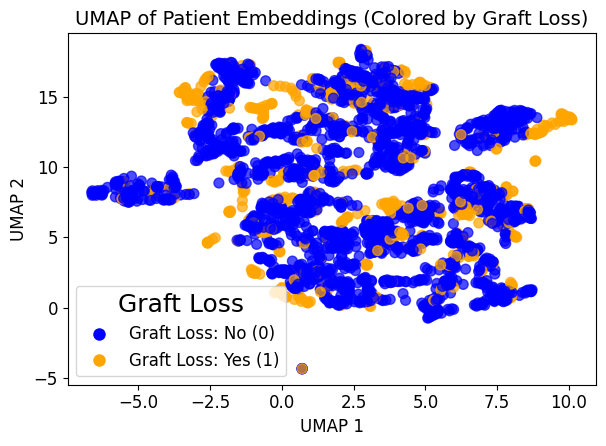

Graft Loss: 586 positive samples, 2796 negative samples


/home/sr100@hsg.privat/x-med/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_81456/2333590586.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c=[colors[int(label)] for label in mort_labels],


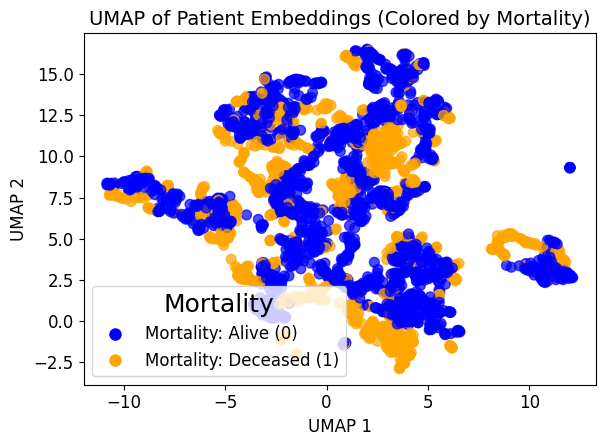

Mortality: 1038 positive samples, 2344 negative samples


In [6]:
from matplotlib.lines import Line2D
import umap
import numpy as np
import os

# Create plots directory if it doesn't exist
os.makedirs("../plots/clustering", exist_ok=True)

# Colors for the two classes
colors = ['blue', 'orange']  # 0=Blue, 1=Orange

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=6,
    min_dist=0.3,
    metric='euclidean',
    random_state=42,
    target_metric='categorical',  # Use categorical metric for label information
    target_weight=0.3  # Weight of 0.5 gives equal importance to data structure and labels
)

# Plot UMAP for Graft Loss
embeds_umap_graft = umap_reducer.fit_transform(embeddings, y=graft_labels)

plt.figure()
scatter = plt.scatter(
    embeds_umap_graft[:, 0],
    embeds_umap_graft[:, 1],
    c=[colors[int(label)] for label in graft_labels],
    alpha=0.7,
    s=50  # Slightly larger points for better visibility
)

# Add a legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Graft Loss: No (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Graft Loss: Yes (1)')
]
plt.legend(handles=legend_elements, title="Graft Loss", loc="best", fontsize=12)
plt.title("UMAP of Patient Embeddings (Colored by Graft Loss)", fontsize=14)
plt.xlabel("UMAP 1", fontsize=12)
plt.ylabel("UMAP 2", fontsize=12)
plt.tight_layout()

plt.savefig("../plots/clustering/graft_loss.png", dpi=300, bbox_inches='tight')
plt.show()

# Count points in each class for graft loss
graft_negative = np.sum(graft_labels == 0)
graft_positive = np.sum(graft_labels == 1)
print(f"Graft Loss: {graft_positive} positive samples, {graft_negative} negative samples")

umap_reducer_mort = umap.UMAP(
    n_components=2,
    n_neighbors=6,
    min_dist=0.3,
    metric='euclidean',
    random_state=42,
    target_metric='categorical',
    target_weight=0.3
)

embeds_umap_mort = umap_reducer_mort.fit_transform(embeddings, y=mort_labels)

plt.figure()
scatter = plt.scatter(
    embeds_umap_mort[:, 0],
    embeds_umap_mort[:, 1],
    c=[colors[int(label)] for label in mort_labels],
    alpha=0.7,
    s=50
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Mortality: Alive (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Mortality: Deceased (1)')
]
plt.legend(handles=legend_elements, title="Mortality", loc="best", fontsize=12)
plt.title("UMAP of Patient Embeddings (Colored by Mortality)", fontsize=14)
plt.xlabel("UMAP 1", fontsize=12)
plt.ylabel("UMAP 2", fontsize=12)
plt.tight_layout()

plt.savefig("../plots/clustering/mortality.png", dpi=300, bbox_inches='tight')
plt.show()

mort_negative = np.sum(mort_labels == 0)
mort_positive = np.sum(mort_labels == 1)
print(f"Mortality: {mort_positive} positive samples, {mort_negative} negative samples")

/tmp/ipykernel_81456/1411840072.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_bin_ids))


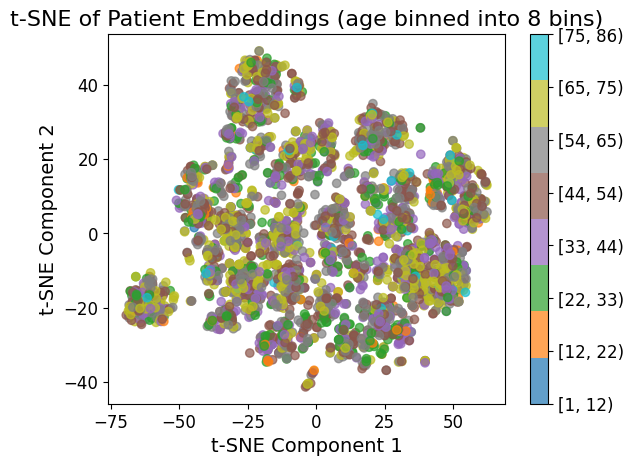

/tmp/ipykernel_81456/1411840072.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_bin_ids))


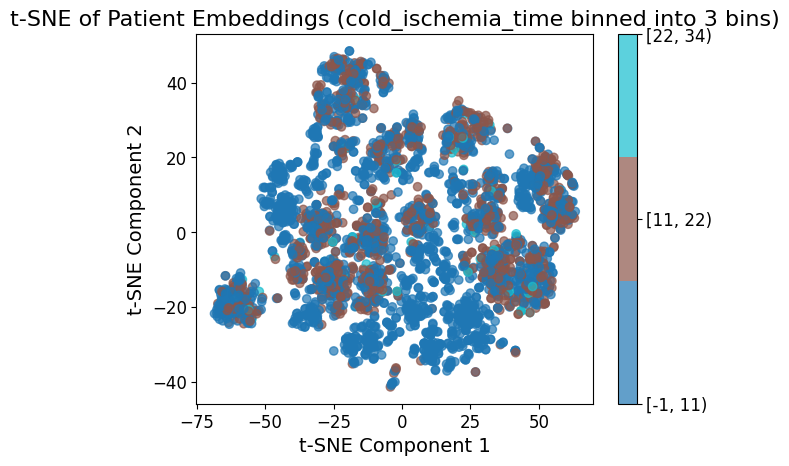

/tmp/ipykernel_81456/1411840072.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_bin_ids))


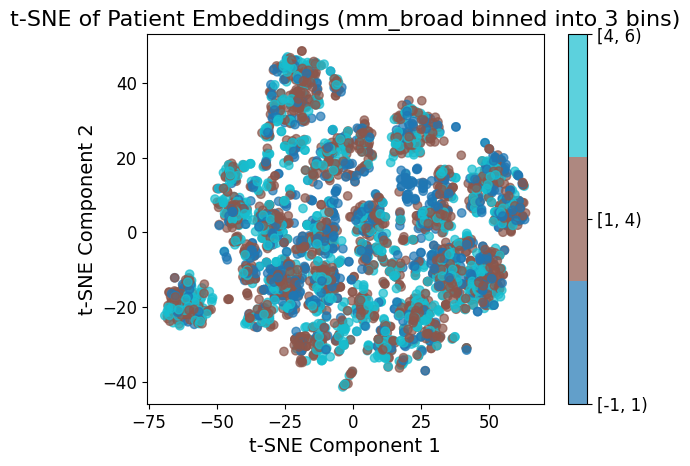

In [7]:
def plot_tsne_numeric_binned(
    embeddings, 
    static_features, 
    feature_name,
    n_bins=5,
    binning_method='quantile',  # 'quantile' or 'uniform'
    decimals=2                  # how many decimals to display in bin labels
):
    """
    Generates a t-SNE plot for patient embeddings, colored by discretized bins 
    of a numerical static feature. The colorbar is labeled with human-readable
    interval boundaries.

    Args:
        embeddings (np.ndarray): Patient representations, shape (N, hidden_dim).
        static_features (np.ndarray): Numerical static features, shape (N, num_features).
        feature_name (str): Name of the numerical feature used for coloring.
        n_bins (int): Number of bins/classes to split the feature into.
        binning_method (str): 'quantile' for equal-frequency bins 
                              or 'uniform' for equal-width bins.
        decimals (int): Number of decimal places to show in the bin range labels.
    """

    # Identify the column index for the desired feature
    feature_index = CONFIG['static_numerical_cols'].index(feature_name)
    
    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=50)
    tsne_results = tsne.fit_transform(embeddings)

    # Extract the continuous feature values
    feature_values = static_features[:, feature_index]

    # Discretize the feature into n_bins
    if binning_method == 'quantile':
        # quantile-based bins: each bin has ~ equal number of data points
        bins = pd.qcut(feature_values, q=n_bins, duplicates='drop') 
    else:
        # uniform/equal-width bins:
        bins = pd.cut(feature_values, bins=n_bins)
    
    # Convert bin labels into integer codes
    bin_codes = bins.codes  # array of 0..(n_bins-1)

    # Create a discrete colormap
    unique_bin_ids = np.unique(bin_codes)
    cmap = plt.cm.get_cmap("tab10", len(unique_bin_ids))
    
    plt.figure()
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        c=bin_codes, 
        cmap=cmap, 
        alpha=0.7
    )
    
    # If the bins object is categorical intervals, format them nicely
    if isinstance(bins, pd.Categorical):
        unique_labels = bins.categories  # list of Interval objects
        cbar = plt.colorbar(scatter, ticks=unique_bin_ids)
        
        # Build a readable string for each bin interval
        formatted_labels = []
        for interval in unique_labels:
            # interval.left, interval.right are the boundaries
            left_str = f"{interval.left:.{decimals}f}"
            right_str = f"{interval.right:.{decimals}f}"
            # You can choose a bracket style. E.g. [left, right) or (left, right]
            label_str = f"[{left_str}, {right_str})"
            formatted_labels.append(label_str)

        # Now set the colorbar ticks to these formatted strings
        cbar.ax.set_yticklabels(formatted_labels)
    else:
        # fallback
        plt.colorbar(scatter)
    
    plt.title(f't-SNE of Patient Embeddings ({feature_name} binned into {n_bins} bins)')
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage:
plot_tsne_numeric_binned(embeddings, static_features, "age", n_bins=8, binning_method='uniform', decimals=0)
plot_tsne_numeric_binned(embeddings, static_features, "cold_ischemia_time", n_bins=3, binning_method='uniform', decimals=0)
plot_tsne_numeric_binned(embeddings, static_features, "mm_broad", n_bins=3, binning_method='uniform', decimals=0)

In [21]:
def plot_tsne_categorical(embeddings, categorical_features, feature_name):
    """
    Generates a t-SNE plot for patient embeddings, colored by a categorical feature.
    Args:
        embeddings (np.ndarray): Patient representations (N, hidden_dim).
        categorical_features (list of lists): Categorical features as string values.
        feature_name (str): The name of the categorical feature used for coloring.
    """
    feature_index = CONFIG['static_categorical_cols'].index(feature_name)  
    tsne = TSNE(n_components=2, perplexity=30)
    tsne_results = tsne.fit_transform(embeddings)
   
    # Extract categorical labels
    feature_labels = np.array(categorical_features)[:, feature_index]
    # Get unique categories and assign colors
    unique_labels = np.unique(feature_labels)
    palette = sns.color_palette("hsv", len(unique_labels))
   
    # Set up figure and remove ticks
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.set_xticks([])
    ax.set_yticks([])
   
    # Create the plot
    for i, label in enumerate(unique_labels):
        indices = feature_labels == label
       
        # Display label for legend (translate German terms for type_of_donation)
        display_label = label
        if feature_name == "type_of_donation":
            if label == "hirntot":
                display_label = "Brain dead"
            elif label == "lebend":
                display_label = "Alive"
               
        plt.scatter(tsne_results[indices, 0], tsne_results[indices, 1],
                    label=display_label, color=palette[i], alpha=0.7)
   
    plt.title(f't-SNE of Patient Embeddings (Colored by {feature_name})')
   
    # Format the feature name with proper capitalization for the legend title
    display_name = feature_name
    if feature_name == "gender":
        display_name = "Gender (Recipient)"
    elif feature_name == "gender_donor":
        display_name = "Gender (Donor)"
    elif feature_name == "type_of_donation":
        display_name = "Type of Donation"
    elif feature_name == "blood_group":
        display_name = "Blood group\n(Recipient)"
    elif feature_name == "donor_bloodgroup":
        display_name = "Blood group\n(Donor)"
   
    # Place legend based on the feature type to avoid hiding data
    if "blood_group" in feature_name or "donor_bloodgroup" in feature_name:
        # For blood group plots, make legend more transparent and place at upper left
        plt.legend(title=display_name, loc='upper left', fontsize='small',
                  framealpha=0.7, edgecolor='lightgray')
    elif feature_name == "gender_donor":
        # For gender donor, also place at top left for consistency
        plt.legend(title=display_name, loc='upper left', fontsize='small',
                  framealpha=0.9, edgecolor='lightgray')
    elif len(unique_labels) > 6:
        # For many categories, place legend at bottom of plot with multiple columns
        plt.legend(title=display_name, loc='lower center', ncol=3, fontsize='small',
                  framealpha=0.9, edgecolor='lightgray')
    else:
        # For fewer categories, try to place in a corner with less data
        plt.legend(title=display_name, loc='best', framealpha=0.9, edgecolor='lightgray')
   
    filename = f"../plots/clustering/{model_name}_{feature_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Example Usage
#plot_tsne_categorical(embeddings, categorical_features, feature_name="gender")
#plot_tsne_categorical(embeddings, categorical_features, feature_name="gender_donor")
#plot_tsne_categorical(embeddings, categorical_features, feature_name="type_of_donation")
#plot_tsne_categorical(embeddings, categorical_features, feature_name="blood_group")
#plot_tsne_categorical(embeddings, categorical_features, feature_name="donor_bloodgroup")

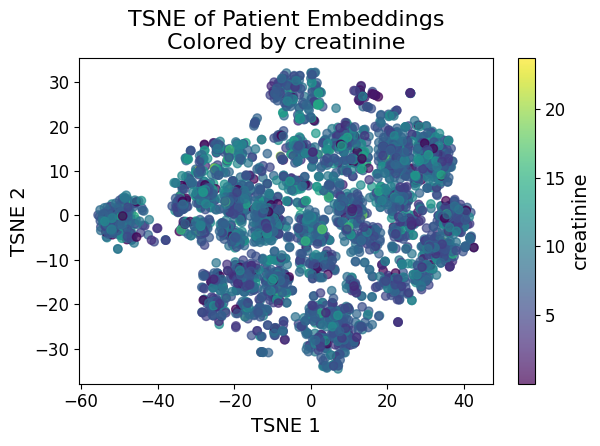

Plot saved to ../plots/clustering/creatinine.png


In [9]:
def plot_tsne_ts_feature(embeddings, all_features, feature_name, config=CONFIG,
                         bin_count=None, save_dir="../plots/clustering"):
    """
    Creates a TSNE visualization of patient embeddings colored by a specific time series feature value.
    
    Args:
        embeddings (np.ndarray): Patient embeddings of shape (N, embedding_dim)
        all_features (np.ndarray): Array containing all feature values of shape (N, num_features)
        feature_name (str): Name of the time series feature to visualize
        config (dict): Configuration dictionary containing feature names
        figsize (tuple): Figure size for the plot
        bin_count (int, optional): If specified, bins the feature values into this many categories
        save_dir (str): Directory to save the plot
    """
    from matplotlib.colors import ListedColormap
    import matplotlib.patches as mpatches
    
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Get feature index
    try:
        feature_idx = config['ts_features'].index(feature_name)
    except ValueError:
        raise ValueError(f"Feature {feature_name} not found in ts_features")
    
    # Extract feature values
    feature_values = all_features[:, feature_idx]
    
    # Compute TSNE
    tsne = TSNE(n_components=2, perplexity=100)
    tsne_results = tsne.fit_transform(embeddings)
    
    # Create plot
    plt.figure()
    
    # Handle binning if requested
    if bin_count is not None:
        # Create uniform bins based on feature range
        min_val, max_val = np.nanmin(feature_values), np.nanmax(feature_values)
        bin_edges = np.linspace(min_val, max_val, bin_count + 1)
        
        # Assign each value to a bin
        binned_values = np.digitize(feature_values, bin_edges) - 1
        binned_values = np.clip(binned_values, 0, bin_count - 1)  # Ensure values are within range
        
        # Create a custom colormap with distinct colors
        colors = plt.cm.tab10(np.linspace(0, 1, bin_count))
        cmap = ListedColormap(colors)
        
        # Plot with binned colors
        scatter = plt.scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=binned_values,
            cmap=cmap,
            alpha=0.7
        )
        
        # Create legend for bins
        bin_labels = []
        for i in range(bin_count):
            if i == 0:
                bin_labels.append(f"{min_val:.2f} - {bin_edges[i+1]:.2f}")
            elif i == bin_count - 1:
                bin_labels.append(f"{bin_edges[i]:.2f} - {max_val:.2f}")
            else:
                bin_labels.append(f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}")
        
        # Add legend patches
        patches = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(bin_labels)]
        plt.legend(handles=patches, title=feature_name, loc='best')
        
        title_suffix = f" (Binned into {bin_count} Categories)"
    else:
        # Original continuous coloring
        scatter = plt.scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=feature_values,
            cmap='viridis',
            alpha=0.7
        )
        plt.colorbar(scatter, label=feature_name)
        title_suffix = ""
    
    plt.title(f'TSNE of Patient Embeddings\nColored by {feature_name}{title_suffix}')
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")
    plt.tight_layout()
    
    # Save the plot
    file_name = f"{feature_name.replace(' ', '_').lower()}"
    if bin_count is not None:
        file_name += f"_binned_{bin_count}"
    plt.savefig(f"{save_dir}/{file_name}.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"Plot saved to {save_dir}/{file_name}.png")

# Example usage with binning:
#plot_tsne_ts_feature(embeddings, all_features, 'bp_sys', bin_count=3)
#plot_tsne_ts_feature(embeddings, all_features_first, 'egfr')
plot_tsne_ts_feature(embeddings, all_features_first, 'creatinine')
#plot_tsne_ts_feature(embeddings, all_features, 'crphp', bin_count=7)
#plot_tsne_ts_feature(embeddings, all_features, 'leukocyte', bin_count=3)
# plot_tsne_ts_feature(embeddings, all_features, 'Tacrolimus', bin_count=5)

# Example usage without binning (original behavior):
#for feat in CONFIG['ts_features']:
#    plot_tsne_ts_feature(embeddings, all_features_max, feat, bin_count=6)

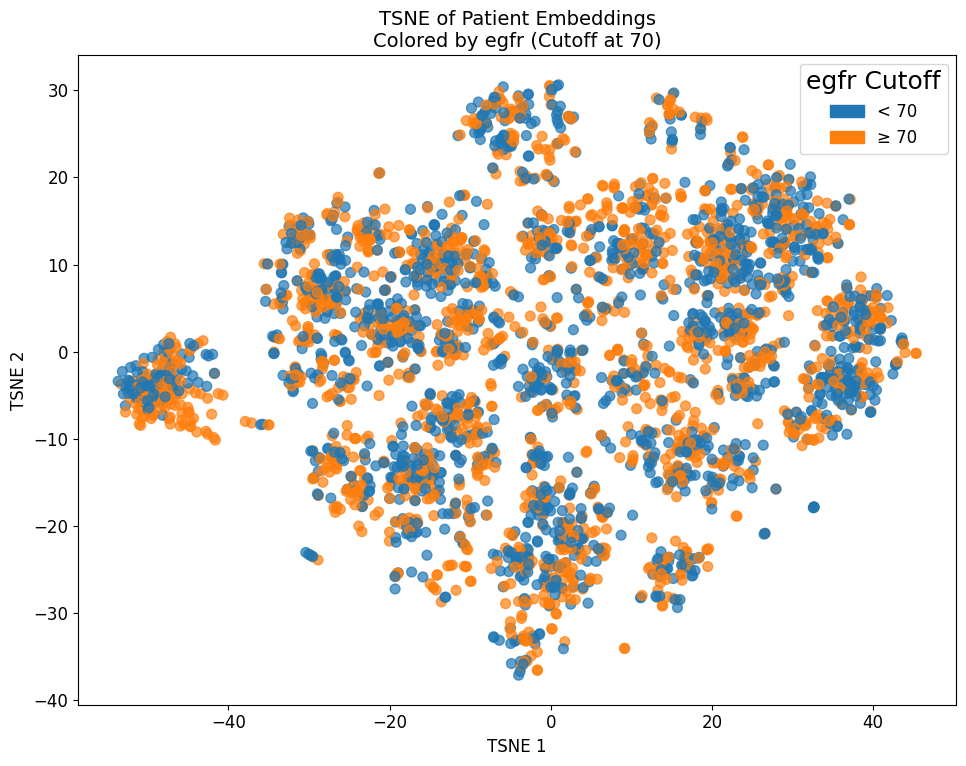

Plot saved to ../plots/clustering/egfr_cutoff_70.png


In [10]:
def plot_tsne_ts_feature(embeddings, all_features, feature_name, config=CONFIG,
                         bin_count=None, cutoff=None, save_dir="../plots/clustering"):
    """
    Creates a TSNE visualization of patient embeddings colored by a specific time series feature value.
    
    Args:
        embeddings (np.ndarray): Patient embeddings of shape (N, embedding_dim)
        all_features (np.ndarray): Array containing all feature values of shape (N, num_features)
        feature_name (str): Name of the time series feature to visualize
        config (dict): Configuration dictionary containing feature names
        bin_count (int, optional): If specified, bins the feature values into this many categories
        cutoff (float, optional): If specified, creates a binary categorization with this as the cutoff value
        save_dir (str): Directory to save the plot
    """
    from matplotlib.colors import ListedColormap
    import matplotlib.patches as mpatches
    
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Get feature index
    try:
        feature_idx = config['ts_features'].index(feature_name)
    except ValueError:
        raise ValueError(f"Feature {feature_name} not found in ts_features")
    
    # Extract feature values
    feature_values = all_features[:, feature_idx]
    
    # Compute TSNE
    tsne = TSNE(n_components=2, perplexity=100)
    tsne_results = tsne.fit_transform(embeddings)
    
    # Create plot
    plt.figure(figsize=(10, 8))
    
    # Handle custom cutoff for binary categorization
    if cutoff is not None:
        # Create binary categorization based on cutoff
        binary_values = (feature_values >= cutoff).astype(int)
        
        # Create a custom colormap with two distinct colors
        colors = ['#1f77b4', '#ff7f0e']  # Blue for below cutoff, orange for above
        cmap = ListedColormap(colors)
        
        # Plot with binary colors
        scatter = plt.scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=binary_values,
            cmap=cmap,
            alpha=0.7,
            s=50  # Slightly larger points for better visibility
        )
        
        # Create legend for the two categories
        below_patch = mpatches.Patch(color=colors[0], label=f"< {cutoff}")
        above_patch = mpatches.Patch(color=colors[1], label=f"≥ {cutoff}")
        plt.legend(handles=[below_patch, above_patch], 
                  title=f"{feature_name} Cutoff", 
                  loc='best', 
                  fontsize=12)
        
        title_suffix = f" (Cutoff at {cutoff})"
        
    # Handle binning if requested
    elif bin_count is not None:
        # Create uniform bins based on feature range
        min_val, max_val = np.nanmin(feature_values), np.nanmax(feature_values)
        bin_edges = np.linspace(min_val, max_val, bin_count + 1)
        
        # Assign each value to a bin
        binned_values = np.digitize(feature_values, bin_edges) - 1
        binned_values = np.clip(binned_values, 0, bin_count - 1)  # Ensure values are within range
        
        # Create a custom colormap with distinct colors
        colors = plt.cm.tab10(np.linspace(0, 1, bin_count))
        cmap = ListedColormap(colors)
        
        # Plot with binned colors
        scatter = plt.scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=binned_values,
            cmap=cmap,
            alpha=0.7
        )
        
        # Create legend for bins
        bin_labels = []
        for i in range(bin_count):
            if i == 0:
                bin_labels.append(f"{min_val:.2f} - {bin_edges[i+1]:.2f}")
            elif i == bin_count - 1:
                bin_labels.append(f"{bin_edges[i]:.2f} - {max_val:.2f}")
            else:
                bin_labels.append(f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}")
        
        # Add legend patches
        patches = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(bin_labels)]
        plt.legend(handles=patches, title=feature_name, loc='best')
        
        title_suffix = f" (Binned into {bin_count} Categories)"
    else:
        # Original continuous coloring
        scatter = plt.scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=feature_values,
            cmap='viridis',
            alpha=0.7
        )
        plt.colorbar(scatter, label=feature_name)
        title_suffix = ""
    
    plt.title(f'TSNE of Patient Embeddings\nColored by {feature_name}{title_suffix}', fontsize=14)
    plt.xlabel("TSNE 1", fontsize=12)
    plt.ylabel("TSNE 2", fontsize=12)
    plt.tight_layout()
    
    # Save the plot
    file_name = f"{feature_name.replace(' ', '_').lower()}"
    if bin_count is not None:
        file_name += f"_binned_{bin_count}"
    if cutoff is not None:
        file_name += f"_cutoff_{cutoff}"
    plt.savefig(f"{save_dir}/{file_name}.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"Plot saved to {save_dir}/{file_name}.png")

# Example usage with custom cutoff for creatinine
# Common clinical cutoff for creatinine is often around 1.3 mg/dL, but you can adjust as needed
plot_tsne_ts_feature(embeddings, all_features_max, 'egfr', cutoff=70)

# To see distribution first to help determine appropriate cutoff
# plt.figure(figsize=(10, 6))
# plt.hist(all_features_first[:, config['ts_features'].index('creatinine')], bins=30)
# plt.title('Distribution of Creatinine Values')
# plt.xlabel('Creatinine')
# plt.ylabel('Count')
# plt.grid(alpha=0.3)
# plt.show()